# Decision Tree and Logistic Regression Experiment Workflow

This notebook mirrors `xaikit_object_workflow.ipynb`, but focuses on the rules-vs-weights experiment setting:

- `decision_tree` / `rules`: tree surrogate path/rule explanation
- `logistic_regression` / `weights`: sparse or dense linear surrogate contribution explanation
- local visualizations: influence and importance
- global visualization: mean class-supporting importance

## Setup

In [1]:
from pathlib import Path
import json
import os
import sys

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = next(p for p in Path.cwd().parents if (p / "src").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

OUTPUT_DIR = REPO_ROOT / "tutorials" / "rules_weights_experiment_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Keep matplotlib/fontconfig caches inside the repo output folder so notebooks
# work even when the home cache directory is not writable.
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / ".mplconfig"))
os.environ.setdefault("XDG_CACHE_HOME", str(OUTPUT_DIR / ".cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

# Some environments mix an older matplotlib runtime with a newer
# matplotlib-inline package. matplotlib-inline>=0.2 calls rcParams._get();
# matplotlib 3.5 only has rcParams.get(). Patch the missing alias for this
# notebook session. If you still see the inline-backend error, restart the
# kernel and run this setup cell before plotting.
import matplotlib
if not hasattr(matplotlib.rcParams, "_get"):
    setattr(type(matplotlib.rcParams), "_get", lambda self, key: self.get(key))

import src.api as xk
from src.xai_adapter import (
    create_xai_method,
    plot_decision_tree_instance_view,
    plot_explanation_visual,
    plot_global_explanation_importance,
    plot_logistic_regression_instance_view,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

OUTPUT_DIR

PosixPath('/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/rules_weights_experiment_output')

## 1. Create Workflow

In [2]:
xaikitTest = xk.xaikitTest(output_dir=OUTPUT_DIR)
xaikitTest

Good afternoon. XAIKitTest is ready for 'xaikit_test'.
Start by choosing the XAI experiment you want to run. Call `xaikitTest.guide_design()` for a concise design guide.


## 2. Design Experiment

This design treats explanation method as the condition that should be counterbalanced with a Bradley balanced Latin square. To make that happen, `xai_method` must be a within-subject IV with `randomization="block"`.

The trial-level `tested_w_xai` factor stays separate: it is balanced within each method block rather than included in the Latin-square block order.

In [3]:
iv_config = {
    "xai_method": {
        "type": "within",
        "randomization": "block",
        "levels": ["decision_tree", "logistic_regression"],
    },
    "tested_w_xai": {
        "type": "within",
        "randomization": "trial",
        "levels": [True, False],
    },
}

cvs = {
    "age_group": ["young", "adult", "senior"],
    "gender": ["male", "female", "other"],
}

dvs = {"forward_accuracy": ["continuous"]}

xaikitTest.set_design(
    iv_config=iv_config,
    cvs=cvs,
    dvs=dvs,
    show=True,
)
xaikitTest.validate(stage="design", strict=False, show=True)


IV configuration:
  xai_method           type=within   randomization=block levels=['decision_tree', 'logistic_regression']
  tested_w_xai         type=within   randomization=trial levels=[True, False]

CVs: ['age_group', 'gender']
DVs: ['forward_accuracy']
XAIKit validation: design
Good afternoon.

Reminders:
  - user_task: Set `user_task` for cognitive simulation.
    Suggestion: Planner-only OK. Supported: counterfactual_simulation, forward_simulation.


XAIKit validation: design
Good afternoon.

Reminders:
  - user_task: Set `user_task` for cognitive simulation.
    Suggestion: Planner-only OK. Supported: counterfactual_simulation, forward_simulation.

Normalized:
  IVs:
    xai_method: decision_tree, logistic_regression
    tested_w_xai: True, False
  DVs: forward_accuracy
  CVs: age_group, gender
  Context:
    dataset_id: not set
    model_name: not set
    model_source: not set
    cognitive_model_id: placeholder
    tasks: not set
    xai_methods: decision_tree, logistic_regression
    xai_types: not set
    xai_faithfulness: not set
    dvs: forward_accuracy

## 3. Prepare Dataset

In [4]:
data = xaikitTest.prepare_dataset(
    dataset_id="wine_quality",
    model_type="mlp",
    use_default_features=True,
    show_available=True,
    show_summary=True,
)

print("Raw feature names:", data.raw_feature_names)
print("Train shape:", data.X_train.shape)
print("Test shape:", data.X_test.shape)

Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 5 model features)
Features  : ['Alcohol', 'Vinegar Taint', 'Sulphates', 'SO2', 'pH']
Encoding  : one-hot
Train set : 1279 samples  (80%)
Test set  : 320 samples  (20%)
Class balance (train) -> class 0: 1105
Class balance (train) -> class 1: 174
First test instanceIds: [434, 213, 1447, 231, 763, 1472, 472, 1327, 766, 19]
Raw feature names: ['Alcohol', 'Vinegar Taint', 'Sulphates', 'SO2', 'pH']
Train shape: (1279, 5)
Test shape: (320, 5)


## 4. Generate Trials With Bradley Latin Square

Latin-square counterbalancing is controlled by `counterbalancing_strategy="balanced_latin_square"`.

For balanced trial randomization, `trials_per_participant` must divide evenly by:

```python
number_of_block_conditions * number_of_trial_level_conditions
```

Here that is `2 xai_method blocks * 2 tested_w_xai levels = 4` cells, so 12 trials per participant is valid. With 2 block conditions, Bradley produces 2 orders; 24 participants cycles evenly through those orders.

In [5]:
n_block_conditions = len(iv_config["xai_method"]["levels"])
n_trial_conditions = len(iv_config["tested_w_xai"]["levels"])
trials_per_participant = 12
participants_per_between_condition = 24

n_balanced_cells = n_block_conditions * n_trial_conditions
assert trials_per_participant % n_balanced_cells == 0, (
    "trials_per_participant must divide evenly across block x trial-level cells: "
    f"{trials_per_participant} trials for {n_balanced_cells} cells"
)

trial_result = xaikitTest.generate_trials(
    model_name="mlp",
    participants_per_between_condition=participants_per_between_condition,
    trials_per_participant=trials_per_participant,
    counterbalancing_strategy="balanced_latin_square",
    trial_randomization_strategy="balanced",
    output_dir="trials",
    preview_rows=8,
    show=True,
)

pd.DataFrame(trial_result.trials).head(12)

Counterbalancing strategy: balanced_latin_square_bradley_1958
Participant assignments: 24 total
Instance pool rows: 300
Trial rows: 288
Exported trial artifacts:
  CSV     : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/rules_weights_experiment_output/trials/trials.csv
  JSON    : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/rules_weights_experiment_output/trials/trials.json
  Summary : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/rules_weights_experiment_output/trials/design_summary.json

Previewing first 8 trial rows:
{'participantId': 1, 'trialId': 1, 'block': 1, 'trialWithinBlock': 1, 'withinCondition': 'decision_tree', 'xai_method': 'decision_tree', 'tested_w_xai': False, 'dataId': 'wine_quality', 'instanceId': '136'}
{'participantId': 1, 'trialId': 2, 'block': 1, 'trialWithinBlock': 2, 'withinCondition': 'decision_tree', 'xai_method': 'decision_tree', 'tested_w_xai': True, 'dataId': 'wine_quality', 'instanceId': '1507'

,participantId,trialId,block,trialWithinBlock,withinCondition,xai_method,tested_w_xai,dataId,instanceId,CV_age_group_levels,CV_gender_levels,model_type
0,1,1,1,1,decision_tree,decision_tree,False,wine_quality,136,young|adult|senior,male|female|other,mlp
1,1,2,1,2,decision_tree,decision_tree,True,wine_quality,1507,young|adult|senior,male|female|other,mlp
2,1,3,1,3,decision_tree,decision_tree,True,wine_quality,789,young|adult|senior,male|female|other,mlp
3,1,4,1,4,decision_tree,decision_tree,False,wine_quality,984,young|adult|senior,male|female|other,mlp
4,1,5,1,5,decision_tree,decision_tree,True,wine_quality,439,young|adult|senior,male|female|other,mlp
5,1,6,1,6,decision_tree,decision_tree,False,wine_quality,1192,young|adult|senior,male|female|other,mlp
6,1,7,2,1,logistic_regression,logistic_regression,False,wine_quality,195,young|adult|senior,male|female|other,mlp
7,1,8,2,2,logistic_regression,logistic_regression,False,wine_quality,1278,young|adult|senior,male|female|other,mlp
8,1,9,2,3,logistic_regression,logistic_regression,True,wine_quality,861,young|adult|senior,male|female|other,mlp
9,1,10,2,4,logistic_regression,logistic_regression,True,wine_quality,299,young|adult|senior,male|female|other,mlp


In [6]:
summary = json.loads(Path(trial_result.summary_path).read_text())
diagnostics = summary["counterbalancing_diagnostics"]

assert summary["counterbalancing_strategy"] == "balanced_latin_square_bradley_1958"
assert diagnostics["position_balanced"] is True
assert diagnostics["immediate_pair_balanced"] is True

latin_square_check = {
    "counterbalancing_strategy": summary["counterbalancing_strategy"],
    "n_conditions": summary["n_conditions"],
    "n_orders": summary["n_orders"],
    "position_balanced": diagnostics["position_balanced"],
    "immediate_pair_balanced": diagnostics["immediate_pair_balanced"],
    "block_counterbalanced_within_ivs": summary["block_counterbalanced_within_ivs"],
    "trial_randomized_within_ivs": summary["trial_randomized_within_ivs"],
}
latin_square_check

{'counterbalancing_strategy': 'balanced_latin_square_bradley_1958',
 'n_conditions': 2,
 'n_orders': 2,
 'position_balanced': True,
 'immediate_pair_balanced': True,
 'block_counterbalanced_within_ivs': {'xai_method': ['decision_tree',
   'logistic_regression']},
 'trial_randomized_within_ivs': {'tested_w_xai': [True, False]}}

In [7]:
orders_df = pd.DataFrame([
    {
        "order_id": order["order_id"],
        "sequence": " -> ".join(str(step.get("xai_method", step)) for step in order["sequence"]),
    }
    for order in summary["orders"]
])

display(orders_df)
display(pd.DataFrame(summary["counterbalancing_diagnostics"]["position_counts"]).fillna(0))
display(pd.DataFrame.from_dict(
    summary["counterbalancing_diagnostics"]["immediate_pair_counts"],
    orient="index",
    columns=["count"],
))

,order_id,sequence
0,1,decision_tree -> logistic_regression
1,2,logistic_regression -> decision_tree


,1,2
"{""xai_method"": ""decision_tree""}",1,1
"{""xai_method"": ""logistic_regression""}",1,1


,count
"{""xai_method"": ""decision_tree""} -> {""xai_method"": ""logistic_regression""}",1
"{""xai_method"": ""logistic_regression""} -> {""xai_method"": ""decision_tree""}",1


## 5. Train AI Model

The surrogate methods explain the trained AI model's predictions, not the ground-truth labels.

In [8]:
xaikitTest.train_AI_model(
    model_type="mlp",
    batch_size=32,
    train_kwargs={"epochs": 100},
    verbose=True,
)

metrics = xaikitTest.evaluate(split="both")
pd.DataFrame(metrics).T

✓ Created new mlp for 'wine_quality'
Epoch 1  loss=0.4283
Epoch 2  loss=0.3261
Epoch 3  loss=0.2956
Epoch 4  loss=0.2857
Epoch 5  loss=0.2795
Epoch 6  loss=0.2795
Epoch 7  loss=0.2759
Epoch 8  loss=0.2748
Epoch 9  loss=0.2790
Epoch 10  loss=0.2725
Epoch 11  loss=0.2711
Epoch 12  loss=0.2727
Epoch 13  loss=0.2721
Epoch 14  loss=0.2721
Epoch 15  loss=0.2718
Epoch 16  loss=0.2684
Epoch 17  loss=0.2712
Epoch 18  loss=0.2690
Epoch 19  loss=0.2674
Epoch 20  loss=0.2688
Epoch 21  loss=0.2675
Epoch 22  loss=0.2669
Epoch 23  loss=0.2670
Epoch 24  loss=0.2650
Epoch 25  loss=0.2666
Epoch 26  loss=0.2671
Epoch 27  loss=0.2660
Epoch 28  loss=0.2652
Epoch 29  loss=0.2655
Epoch 30  loss=0.2641
Epoch 31  loss=0.2654
Epoch 32  loss=0.2630
Epoch 33  loss=0.2635
Epoch 34  loss=0.2643
Epoch 35  loss=0.2650
Epoch 36  loss=0.2632
Epoch 37  loss=0.2667
Epoch 38  loss=0.2619
Epoch 39  loss=0.2613
Epoch 40  loss=0.2653
Epoch 41  loss=0.2618
Epoch 42  loss=0.2606
Epoch 43  loss=0.2595
Epoch 44  loss=0.2585
Epoc

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,confusion_matrix,labels,precision,recall,f1,roc_auc,average_precision
train,0.899922,0.707237,0.815064,0.707237,0.74493,0.889384,0.899922,0.889662,"[[1074, 31], [97, 77]]","[0, 1]",0.712963,0.442529,0.546099,0.915764,0.653249
test,0.90625,0.719923,0.831121,0.719923,0.759398,0.897212,0.90625,0.896852,"[[270, 7], [23, 20]]","[0, 1]",0.740741,0.465116,0.571429,0.856015,0.640892


## 6. Generate Decision Tree and Logistic Regression Explanations

The generic `xaikitTest.explanations(...)` path is designed for methods that can explain directly after construction, such as SHAP/LIME/LOFO. The rules-vs-weights surrogates must first be fitted to the trained AI model predictions, so this notebook uses the direct fitted-adapter flow.

The resulting `combined_explanations` table still uses the same project explanation schema, so the existing visualization functions work unchanged.

In [9]:
max_explanation_instances = 300
X_explain = data.X_test[:max_explanation_instances]
instance_ids = np.asarray(data.test_instance_ids)[:max_explanation_instances]

ai_predictions = xaikitTest.trained_ai_model.predict(X_explain)
if np.asarray(ai_predictions).ndim == 2:
    y_surrogate = np.argmax(ai_predictions, axis=1)
else:
    y_surrogate = np.asarray(ai_predictions).astype(int)

surrogate_labels = np.unique(y_surrogate)
if len(surrogate_labels) != 2:
    raise ValueError(
        "Rules-vs-weights surrogate generation needs two predicted classes. "
        f"The trained AI model predicted only {surrogate_labels.tolist()} in the explanation set. "
        "Train longer, inspect model quality, or increase max_explanation_instances."
    )

rules = create_xai_method(
    "rules",
    app_id=data.dataset_id,
    model_name="mlp",
    depth=3,
    feature_names=data.raw_feature_names,
).fit(X_explain, y_surrogate)

weights = create_xai_method(
    "weights",
    app_id=data.dataset_id,
    model_name="mlp",
    variant="sparse",
    top_k=3,
    feature_names=data.raw_feature_names,
).fit(X_explain, y_surrogate)

rules_result = rules.explain(X_explain)
weights_result = weights.explain(X_explain)

rules_df = rules_result.to_explanation_df(
    instance_ids=instance_ids,
    predictions=y_surrogate,
    dataset_id=data.dataset_id,
    model_name="mlp",
)
weights_df = weights_result.to_explanation_df(
    instance_ids=instance_ids,
    predictions=y_surrogate,
    dataset_id=data.dataset_id,
    model_name="mlp",
)

combined_explanations = pd.concat([rules_df, weights_df], ignore_index=True)
combined_path = OUTPUT_DIR / "generated_explanation" / f"de_mlp_{data.dataset_id}.csv"
combined_path.parent.mkdir(parents=True, exist_ok=True)
combined_explanations.to_csv(combined_path, index=False)

xaikitTest.combined_explanations = combined_explanations
xaikitTest.combined_explanation_path = combined_path

print("Combined explanation path:", combined_path)
combined_explanations.head()

Combined explanation path: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/rules_weights_experiment_output/generated_explanation/de_mlp_wine_quality.csv


,dataId,modelName,expMethod,instanceId,pred,i_max,a0_i,a1_i,a2_i,a3_i,a4_i,intercept
0,wine_quality,mlp,decision_tree,434,0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
1,wine_quality,mlp,decision_tree,213,0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
2,wine_quality,mlp,decision_tree,1447,0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
3,wine_quality,mlp,decision_tree,231,0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
4,wine_quality,mlp,decision_tree,763,0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


In [10]:
combined_explanations["expMethod"].value_counts()

expMethod
decision_tree          300
logistic_regression    300
Name: count, dtype: int64

## 7. Direct Adapter Sanity Checks

This smaller check fits fresh `rules` and `weights` adapters on eight rows so their raw outputs are easy to inspect outside the full explanation table.

In [11]:
probe_indices = []
for label in np.unique(y_surrogate):
    label_indices = np.flatnonzero(y_surrogate == label)
    probe_indices.extend(label_indices[:4].tolist())
probe_indices = np.asarray(sorted(probe_indices), dtype=int)

X_probe = X_explain[probe_indices]
y_probe = y_surrogate[probe_indices]

print("Probe class counts:", pd.Series(y_probe).value_counts().sort_index().to_dict())

probe_rules = create_xai_method(
    "rules",
    app_id="wine_quality_probe",
    model_name="mlp",
    depth=3,
    feature_names=data.raw_feature_names,
).fit(X_probe, y_probe)

probe_weights = create_xai_method(
    "weights",
    app_id="wine_quality_probe",
    model_name="mlp",
    variant="sparse",
    top_k=3,
    feature_names=data.raw_feature_names,
).fit(X_probe, y_probe)

probe_rules_result = probe_rules.explain(X_probe)
probe_weights_result = probe_weights.explain(X_probe)

print("Decision tree values shape:", probe_rules_result.values.shape)
print("Logistic regression values shape:", probe_weights_result.values.shape)
print("Decision tree predictions:", [p["class_index"] for p in probe_rules_result.metadata["predictions"]])
print("Logistic regression probabilities:", probe_weights_result.metadata["predictions"])

display(pd.DataFrame(probe_rules_result.values, columns=data.raw_feature_names).add_prefix("rule_path_"))
display(pd.DataFrame(probe_weights_result.values, columns=data.raw_feature_names).add_prefix("weight_contribution_"))

Probe class counts: {0: 4, 1: 4}
Decision tree values shape: (8, 5)
Logistic regression values shape: (8, 5)
Decision tree predictions: [0, 0, 0, 0, 1, 1, 1, 1]
Logistic regression probabilities: [0.50788876 0.33203766 0.34453426 0.41756022 0.67265978 0.72689206
 0.71602092 0.6484538 ]


,rule_path_Alcohol,rule_path_Vinegar Taint,rule_path_Sulphates,rule_path_SO2,rule_path_pH
0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0
7,1.0,0.0,0.0,0.0,0.0


,weight_contribution_Alcohol,weight_contribution_Vinegar Taint,weight_contribution_Sulphates,weight_contribution_SO2,weight_contribution_pH
0,0.211988,-0.239932,0.471954,0.0,0.0
1,0.272556,-0.514139,-0.044948,0.0,0.0
2,0.151420,-0.685519,0.303399,0.0,0.0
3,0.211988,-0.188518,0.056185,0.0,0.0
4,0.757100,-0.051414,0.427006,0.0,0.0
5,1.090224,-0.137104,0.438243,0.0,0.0
6,1.029656,-0.085690,0.393295,0.0,0.0
7,0.666248,-0.068552,0.427006,0.0,0.0


## 8. Stored Format Checks

The decision-tree table stores a custom sklearn-like JSON node list. The logistic-regression table stores an intercept plus `coef_aN` columns.

In [12]:
decision_tree_table = rules.to_explanation_table()
logistic_table = weights.to_explanation_table()
metadata_table = rules.to_metadata_table()

display(decision_tree_table)
display(logistic_table)
display(metadata_table)

tree_nodes = json.loads(decision_tree_table.iloc[0]["tree_structure"])
print("First tree node:")
display(pd.DataFrame(tree_nodes).head())

required_node_fields = {"node", "feature", "threshold", "left", "right", "value", "is_leaf"}
assert required_node_fields.issubset(tree_nodes[0].keys())
assert "intercept" in logistic_table.columns
assert any(col.startswith("coef_a") for col in logistic_table.columns)

,dataId,model,depth,fidelity,tree_structure,class_labels
0,wine_quality,mlp,3,0.98,"[{""node"": 0, ""feature"": ""a0"", ""threshold"": 0.5...","[0, 1]"


,dataId,model,variant,fidelity,intercept,C,nnz,k,coef_a0,coef_a1,coef_a2,kept_groups
0,wine_quality,mlp,sparse,0.913333,-2.966517,1.0,3,3,3.483566,-1.981377,1.603921,"[""a0"", ""a1"", ""a2""]"


,dataId,a0,v0_min,v0_max,a1,v1_min,v1_max,a2,v2_min,v2_max,a3,v3_min,v3_max,a4,v4_min,v4_max
0,wine_quality,Alcohol,-0.242424,1.454545,Vinegar Taint,-0.157895,1.859649,Sulphates,-0.217391,3.282609,SO2,-0.049456,2.749753,pH,-0.392157,1.862745


First tree node:


,node,feature,threshold,left,right,value,is_leaf
0,0,a0,0.590909,1.0,6.0,"[0.9133333333333333, 0.08666666666666667]",False
1,1,a2,0.891304,2.0,3.0,"[0.9874476987447699, 0.012552301255230125]",False
2,2,None,NaN,NaN,NaN,"[1.0, 0.0]",True
3,3,a0,0.500000,4.0,5.0,"[0.8571428571428571, 0.14285714285714285]",False
4,4,None,NaN,NaN,NaN,"[0.9473684210526315, 0.05263157894736842]",True


## 9. Visualize Local Explanations

These views mirror the CoXAM-style instance displays: logistic regression uses the fitted factor/partial-sum table, and decision tree uses the fitted tree structure and depth.


In [13]:
example_instance_id = combined_explanations.iloc[0]["instanceId"]
example_position = int(np.flatnonzero(instance_ids.astype(str) == str(example_instance_id))[0])
example_instance = X_explain[example_position]

print("Example instance id:", example_instance_id)
print("Example position in X_explain:", example_position)


Example instance id: 434
Example position in X_explain: 0


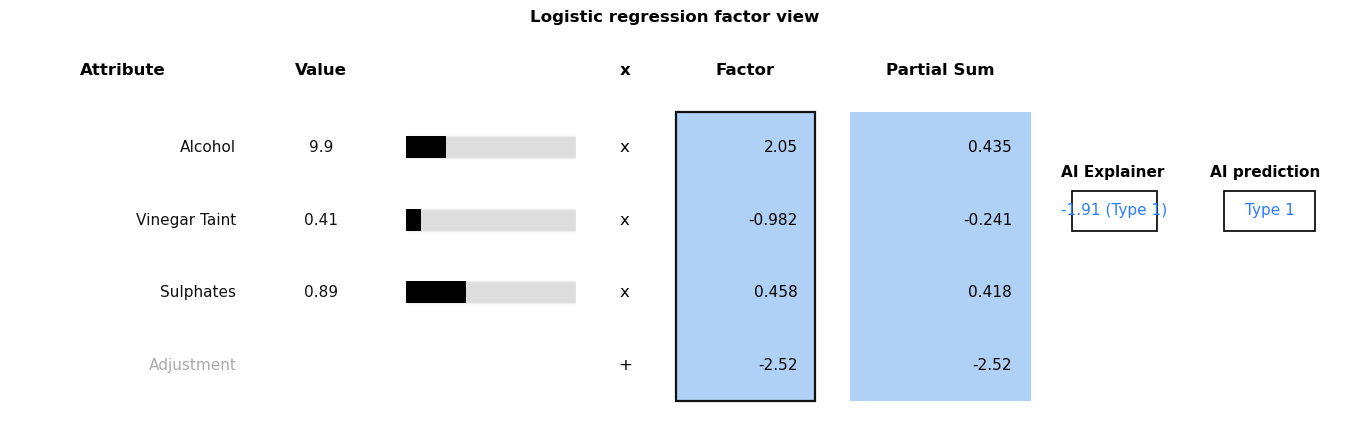

In [14]:
plot_logistic_regression_instance_view(
    weights,
    example_instance,
    data=data,
    instance_id=example_instance_id,
    feature_names=data.raw_feature_names,
    class_labels=["Type 1", "Type 2"],
    title="Logistic regression factor view",
);


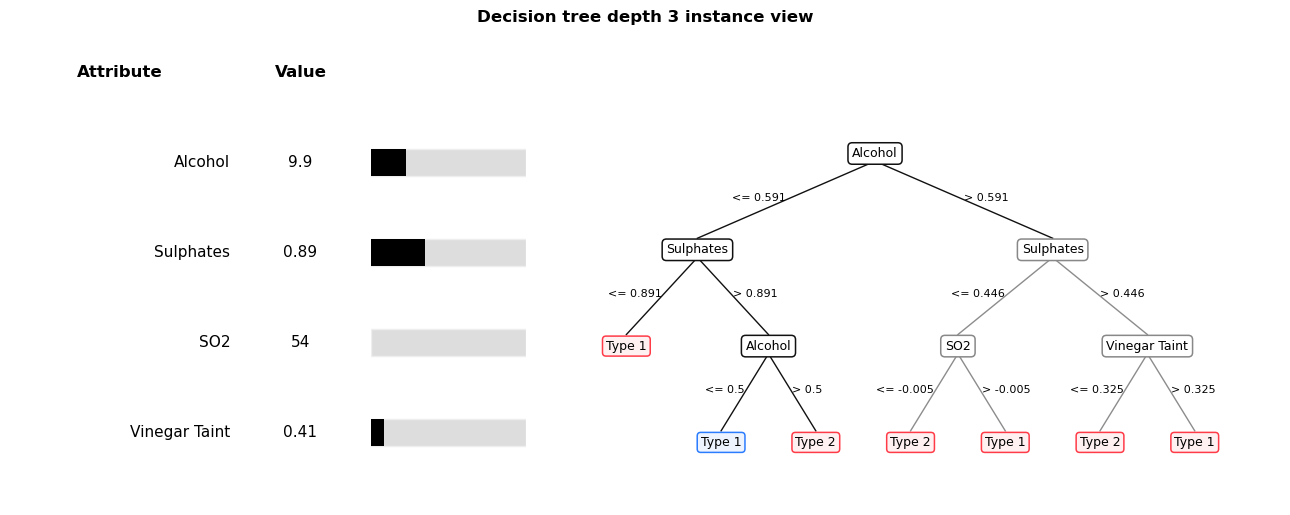

In [15]:
plot_decision_tree_instance_view(
    rules,
    example_instance,
    data=data,
    instance_id=example_instance_id,
    feature_names=data.raw_feature_names,
    class_labels=["Type 1", "Type 2"],
    title=f"Decision tree depth {rules.depth} instance view",
);


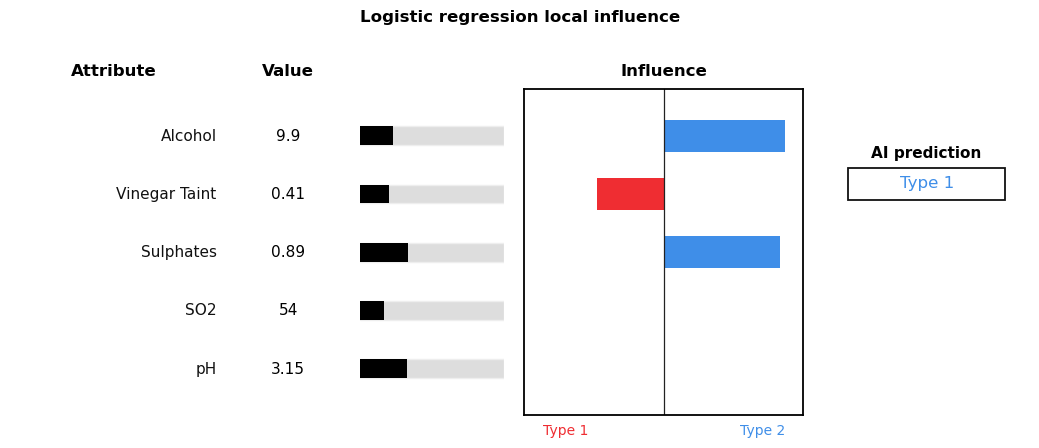

In [16]:
# Optional generic signed-contribution view from the normalized explanation table.
plot_explanation_visual(
    combined_explanations,
    data,
    visualization="influence",
    method="logistic_regression",
    instance_id=example_instance_id,
    feature_names=data.raw_feature_names,
    top_n=5,
    title="Logistic regression local influence",
);


## 11. What This Notebook Checks

- The experiment design places `decision_tree` and `logistic_regression` in a within-subject block factor.
- Trial generation uses explicit Bradley balanced Latin square counterbalancing.
- The notebook checks that trial counts divide evenly across block x trial-level cells.
- The notebook displays Latin-square orders, position counts, and immediate-pair counts.
- Decision-tree surrogate tables contain a JSON `tree_structure` with node/split/child/value fields.
- Logistic-regression surrogate tables contain `intercept` and `coef_aN` columns.
- Existing visualization functions work for local influence, local importance, and global importance.